In [74]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from ddm_core import simulate_ddm, ddm_log_likelihood

In [76]:
np.random.seed(42)

In [77]:
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
data = simulate_ddm(**true_params, n_trials=500)

# Evaluate at true params - should be highest
ll_true = ddm_log_likelihood(data, v=0.3, a=1.2, z=0.5, t0=0.15)

# Evaluate at perturbed params - should be lower
ll_wrong_v = ddm_log_likelihood(data, v=0.8, a=1.2, z=0.5, t0=0.15)
ll_wrong_a = ddm_log_likelihood(data, v=0.3, a=2.5, z=0.5, t0=0.15)
ll_wrong_z = ddm_log_likelihood(data, v=0.3, a=1.2, z=0.2, t0=0.15)

print(ll_true, ll_wrong_v, ll_wrong_a, ll_wrong_z)
# True params must give higher (less negative) value
assert ll_true > ll_wrong_a, "Something is wrong with the likelihood"
assert ll_true > ll_wrong_v, "Something is wrong with the likelihood"
assert ll_true > ll_wrong_z, "Something is wrong with the likelihood"

-314.8649409711593 -336.7177659711594 -30000001199.617413 -629.1159539535538


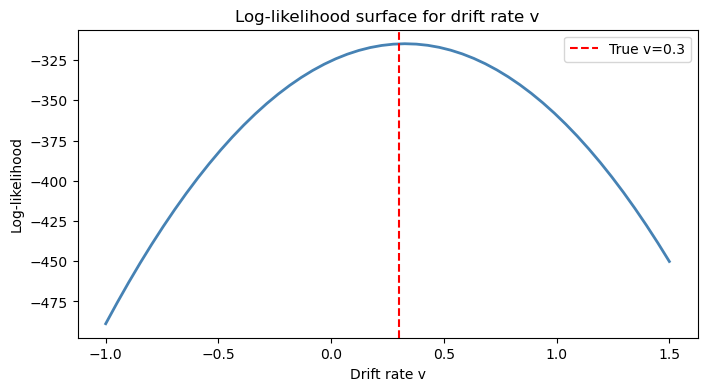

In [78]:
# Scan likelihood across a range of v values
# This shows you the likelihood surface for one parameter

v_range = np.linspace(-1.0, 1.5, 50)
log_liks = []

for v_test in v_range:
    ll = ddm_log_likelihood(data, v=v_test, a=1.2, z=0.5, t0=0.15)
    log_liks.append(ll)

plt.figure(figsize=(8, 4))
plt.plot(v_range, log_liks, color='steelblue', linewidth=2)
plt.axvline(x=0.3, color='red', linestyle='--', label='True v=0.3')
plt.xlabel('Drift rate v')
plt.ylabel('Log-likelihood')
plt.title('Log-likelihood surface for drift rate v')
plt.legend()
plt.show()

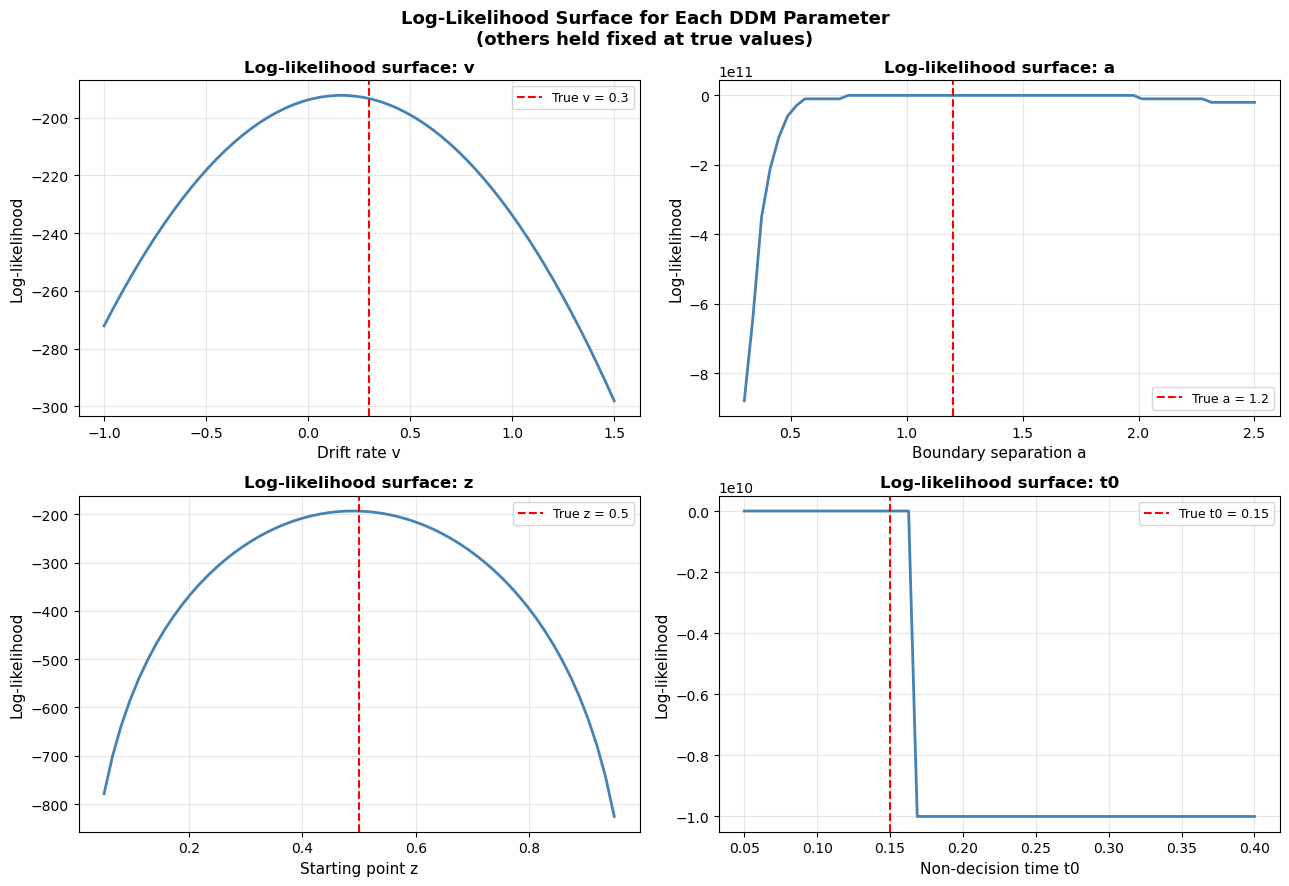

Saved.


In [79]:
# Generate data from known parameters
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
data = simulate_ddm(**true_params, n_trials=300)

# Define scan ranges for each parameter
# Hold all others fixed at true values while varying one
scan_ranges = {
    'v':  np.linspace(-1.0, 1.5, 60),
    'a':  np.linspace(0.3,  2.5, 60),
    'z':  np.linspace(0.05, 0.95, 60),
    't0': np.linspace(0.05, 0.40, 60)
}

true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
labels = {
    'v':  'Drift rate v',
    'a':  'Boundary separation a',
    'z':  'Starting point z',
    't0': 'Non-decision time t0'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for idx, param in enumerate(['v', 'a', 'z', 't0']):
    ax = axes[idx // 2, idx % 2]
    log_liks = []

    for val in scan_ranges[param]:
        # Build parameter dict with this param varied, others fixed
        kwargs = {
            'v':  true_vals['v'],
            'a':  true_vals['a'],
            'z':  true_vals['z'],
            't0': true_vals['t0']
        }
        kwargs[param] = val

        ll = ddm_log_likelihood(data, **kwargs)
        log_liks.append(ll)

    ax.plot(scan_ranges[param], log_liks,
            color='steelblue', linewidth=2)
    ax.axvline(x=true_vals[param], color='red',
               linestyle='--', linewidth=1.5,
               label=f'True {param} = {true_vals[param]}')

    ax.set_xlabel(labels[param], fontsize=11)
    ax.set_ylabel('Log-likelihood', fontsize=11)
    ax.set_title(f'Log-likelihood surface: {param}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Log-Likelihood Surface for Each DDM Parameter\n'
             '(others held fixed at true values)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('likelihood_surfaces.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

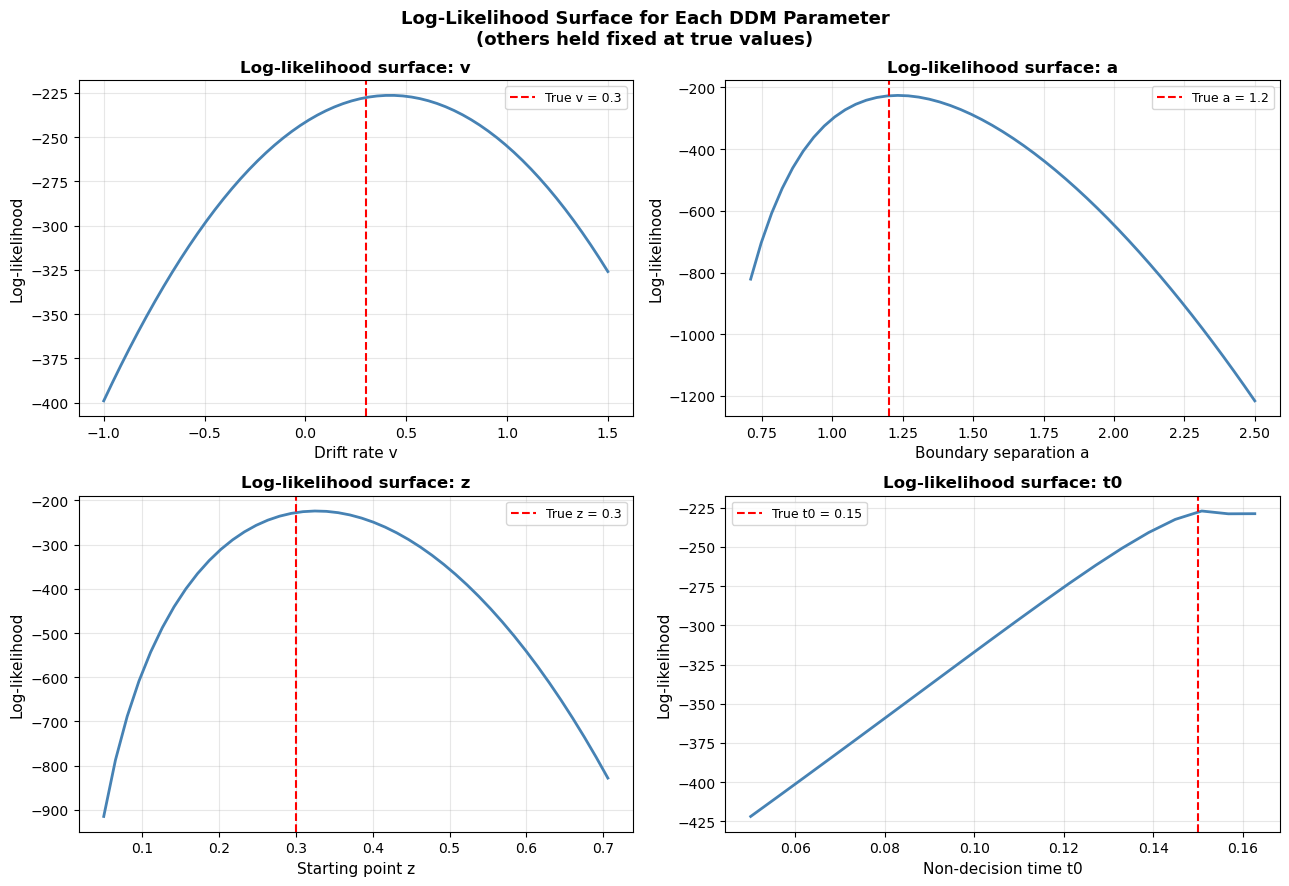

Saved.


In [92]:
# Generate data from known parameters
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.3,'t0': 0.15}
data = simulate_ddm(**true_params, n_trials=500)

# Define scan ranges for each parameter
# Hold all others fixed at true values while varying one
scan_ranges = {
    'v':  np.linspace(-1.0, 1.5, 60),
    'a':  np.linspace(0.3,  2.5, 60),
    'z':  np.linspace(0.05, 0.95, 60),
    't0': np.linspace(0.05, 0.40, 60)
}

true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.3,'t0': 0.15}
labels = {
    'v':  'Drift rate v',
    'a':  'Boundary separation a',
    'z':  'Starting point z',
    't0': 'Non-decision time t0'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for idx, param in enumerate(['v', 'a', 'z', 't0']):
    ax = axes[idx // 2, idx % 2]
    log_liks = []

    for val in scan_ranges[param]:
        # Build parameter dict with this param varied, others fixed
        kwargs = {
            'v':  true_vals['v'],
            'a':  true_vals['a'],
            'z':  true_vals['z'],
            't0': true_vals['t0']
        }
        kwargs[param] = val

        ll = ddm_log_likelihood(data, **kwargs)
        log_liks.append(ll)

    log_liks = np.array(log_liks, dtype=float)
    log_liks[log_liks < -1e9] = np.nan
    ax.plot(scan_ranges[param], log_liks,
            color='steelblue', linewidth=2)
    ax.axvline(x=true_vals[param], color='red',
               linestyle='--', linewidth=1.5,
               label=f'True {param} = {true_vals[param]}')

    ax.set_xlabel(labels[param], fontsize=11)
    ax.set_ylabel('Log-likelihood', fontsize=11)
    ax.set_title(f'Log-likelihood surface: {param}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Log-Likelihood Surface for Each DDM Parameter\n'
             '(others held fixed at true values)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('likelihood_surface1.png',dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

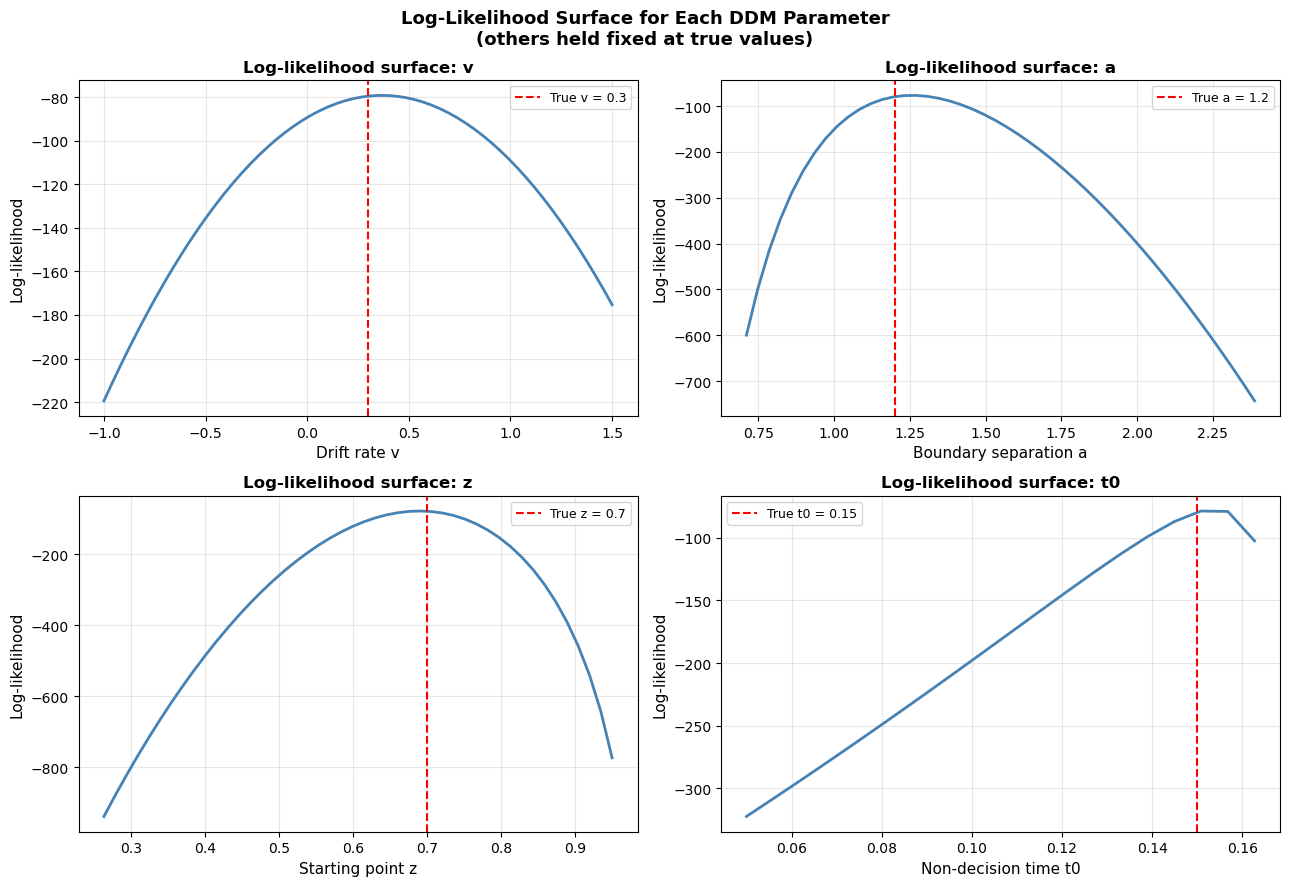

Saved.


In [91]:
# Generate data from known parameters
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.7,'t0':0.15}
data = simulate_ddm(**true_params, n_trials=500)

# Define scan ranges for each parameter
# Hold all others fixed at true values while varying one
scan_ranges = {
    'v':  np.linspace(-1.0, 1.5, 60),
    'a':  np.linspace(0.3,  2.5, 60),
    'z':  np.linspace(0.05, 0.95, 60),
    't0': np.linspace(0.05, 0.40, 60)
}

true_vals = {'v': 0.3, 'a': 1.2, 'z':0.7,'t0':0.15}
labels = {
    'v':  'Drift rate v',
    'a':  'Boundary separation a',
    'z':  'Starting point z',
    't0': 'Non-decision time t0'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for idx, param in enumerate(['v', 'a', 'z', 't0']):
    ax = axes[idx // 2, idx % 2]
    log_liks = []

    for val in scan_ranges[param]:
        # Build parameter dict with this param varied, others fixed
        kwargs = {
            'v':  true_vals['v'],
            'a':  true_vals['a'],
            'z':  true_vals['z'],
            't0': true_vals['t0']
        }
        kwargs[param] = val

        ll = ddm_log_likelihood(data, **kwargs)
        log_liks.append(ll)

    log_liks = np.array(log_liks, dtype=float)
    log_liks[log_liks < -1e9] = np.nan
    ax.plot(scan_ranges[param], log_liks,
            color='steelblue', linewidth=2)
    ax.axvline(x=true_vals[param], color='red',
               linestyle='--', linewidth=1.5,
               label=f'True {param} = {true_vals[param]}')

    ax.set_xlabel(labels[param], fontsize=11)
    ax.set_ylabel('Log-likelihood', fontsize=11)
    ax.set_title(f'Log-likelihood surface: {param}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Log-Likelihood Surface for Each DDM Parameter\n'
             '(others held fixed at true values)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('likelihood_surface2.png',dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")